In [56]:
import torch
from gsnn.models.GSNN import GSNN
from gsnn.interpret.GSNNExplainer import GSNNExplainer
from gsnn.interpret.ContrastiveIGExplainer import ContrastiveIGExplainer
import pandas as pd
import numpy as np
import networkx as nx
from matplotlib import pyplot as plt
from gsnn_mds.data.AMLDataset import AMLDataset
from gsnn_mds.subgroup.eval_subgroup import eval_subgroup

from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests 

import seaborn as sbn 

%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Drug-resistance GOF mutations 

Our goal is to identify MDS mutations that are predicted to induce resistance to a given drug. 

In [ ]:
min_mds_mutation_frequency = 0.02       # mutation candidates must be present in at least X% of MDS patients 
min_drug_spearman_r = 0.5              # drug candidates must have strong predictive performance in MDS  
min_sample_size = 3                     # minimum number of MDS patients in subgroup 

In [ ]:
mds_preds = pd.read_csv('mds_predictions.csv', low_memory=False) 
lls_muts = pd.read_excel('lls_mds_clin_muts-09-12-2025.xlsx')
mds_muts = pd.read_excel('../../data/evansmds/805_data_20250107.xlsx') 
gsnn_res = pd.read_csv('../../workflow_outputs/gsnn-mds/exp/default/gsnn/stratified_results.csv')


In [ ]:

lls_muts2 = lls_muts.assign(mut_freq = lambda x: x.n / lls_muts.n.sum()) 
lls_muts2 = lls_muts2.assign(mut_candidate = lambda x: x.gene_name.isin(mut_candidates) & (x.gene_name.isin(mds_muts.columns.tolist())))
mut_candidates = lls_muts2[lambda x: x.mut_candidate].gene_name.unique().tolist()
print('# mutation candidates:', len(mut_candidates))

# mutation candidates: 11


In [98]:
lls_muts2.head(15) 

,gene_name,n,mut_freq,mut_candidate
0,TP53,16,0.095238,True
1,ASXL1,15,0.089286,True
2,TET2,15,0.089286,True
3,CEBPA,10,0.059524,True
4,DNMT3A,9,0.053571,True
5,STAG2,9,0.053571,True
6,RUNX1,9,0.053571,True
7,CBL,8,0.047619,True
8,EZH2,8,0.047619,True
9,BCOR,8,0.047619,True


In [53]:
# filter to drugs that  have strong predictive performance in MDS 
gsnn_res2 = gsnn_res[lambda x: x.drug_combination != 'overall']
gsnn_res2 = gsnn_res2[lambda x: x.spearman_r > min_drug_spearman_r]
gsnn_res2 = gsnn_res2.assign(inhibitor_1 = [x if '+' not in x else x.split('+')[0] for x in gsnn_res2.drug_combination])
gsnn_res2 = gsnn_res2.assign(inhibitor_2 = [None if '+' not in x else x.split('+')[1] for x in gsnn_res2.drug_combination])

high_perf_inhibitor_candidates = gsnn_res2[['inhibitor_1', 'inhibitor_2']].drop_duplicates().reset_index(drop=True)

print('# drug candidates:', high_perf_inhibitor_candidates.shape[0])
print(set(high_perf_inhibitor_candidates.inhibitor_1.unique().tolist() + high_perf_inhibitor_candidates.inhibitor_2.unique().tolist()))

# drug candidates: 36
{'mgcd-265', 'venetoclax', 'axitinib (ag-013736)', 'rapamycin', None, 'quizartinib (ac220)', 'jq1', 'lenvatinib', 'cabozantinib', 'crenolanib', 'jnk inhibitor ii', 'saracatinib (azd0530)', 'pi-103', 'pp242', 'selumetinib (azd6244)', 'vargetef', 'ci-1040 (pd184352)', 'otx-015', 'gw-2580 ', ' sorafenib', 'birinapant ', ' palbociclib', 'foretinib (xl880)', 'bosutinib (ski-606)', 'dasatinib', '17-aag (tanespimycin)', 'trametinib (gsk1120212)', 'nvp-tae684', 'regorafenib (bay 73-4506)', 'gilteritinib', 'tivozanib (av-951)', 'gdc-0941', ' gw-2580', ' rapamycin', 'sunitinib', ' jq1', 'sns-032 (bms-387032)', 'motesanib (amg-706)', 'dasatinib ', 'jq1 ', ' otx-015'}


In [ ]:
high_perf_inhibitor_candidates.head()

In [55]:
res = []
for i, gene in enumerate(mut_candidates):  
    print(f'progress: {i}/{len(mut_candidates)} [gene: {gene}]')
    subgroup_ids = mds_muts[lambda x: x[gene] == 'POSITIVE']['MLL ID'].unique().tolist() 
    res.append(eval_subgroup(mds_preds, subgroup_ids, high_perf_inhibitor_candidates, gene, min_sample_size))

res = pd.concat(res)
res = res.assign(fdr = lambda x: multipletests(x.pval.fillna(1), method='fdr_bh')[1])
res.head() 


progress: 0/11 [gene: TP53]
progress: 1/11 [gene: ASXL1]
progress: 2/11 [gene: TET2]
progress: 3/11 [gene: CEBPA]
progress: 4/11 [gene: DNMT3A]
progress: 5/11 [gene: STAG2]
progress: 6/11 [gene: RUNX1]
progress: 7/11 [gene: CBL]
progress: 8/11 [gene: EZH2]
progress: 9/11 [gene: BCOR]
progress: 10/11 [gene: SF3B1]


,drug1,drug2,subgroup_y_mean,subgroup_y_std,rest_y_mean,rest_y_std,pval,test_stat,subgroup_n,rest_n,test_method,mut_subgroup,mean_diff,fdr
0,17-aag (tanespimycin),None,-0.419287,0.218680,-0.516210,0.195511,0.000112,31760.0,87,581,mannwhitneyu,TP53,0.096923,0.001535
1,axitinib (ag-013736),None,0.179950,0.254264,0.177309,0.221453,0.988118,25248.0,87,581,mannwhitneyu,TP53,0.002640,0.988118
2,bosutinib (ski-606),None,0.241561,0.329318,0.273407,0.288143,0.526193,24209.0,87,581,mannwhitneyu,TP53,-0.031846,0.697364
3,ci-1040 (pd184352),None,0.172709,0.211430,0.206040,0.194996,0.065401,22180.0,87,581,mannwhitneyu,TP53,-0.033331,0.190993
4,cabozantinib,None,-0.008097,0.235668,-0.036197,0.225638,0.373157,26769.0,87,581,mannwhitneyu,TP53,0.028101,0.552205


In [66]:
top_hits = res.sort_values('fdr', ascending=True).head(10)
top_hits[['drug1', 'drug2', 'mut_subgroup', 'test_stat', 'fdr', 'mean_diff', 'subgroup_n']]


,drug1,drug2,mut_subgroup,test_stat,fdr,mean_diff,subgroup_n
18,sns-032 (bms-387032),None,TP53,35333.0,6.832636e-07,0.167338,87
28,otx-015,None,TET2,31442.0,1.415283e-06,-0.107792,182
28,otx-015,None,TP53,34447.0,5.109668e-06,0.135951,87
18,sns-032 (bms-387032),None,STAG2,20231.0,1.215868e-05,0.166358,44
6,dasatinib,None,STAG2,20104.0,1.690527e-05,0.304101,44
6,dasatinib,None,ASXL1,44014.0,4.391116e-05,0.177370,127
23,trametinib (gsk1120212),None,STAG2,19753.0,4.616251e-05,0.287859,44
10,mgcd-265,None,SF3B1,57520.0,4.616251e-05,0.070608,197
20,selumetinib (azd6244),None,STAG2,19440.0,1.431249e-04,0.192804,44
27,venetoclax,None,STAG2,8219.0,2.802474e-04,-0.158139,44


In [65]:
top_ven_hits = res[lambda x: x.drug1 == 'venetoclax'].sort_values('fdr', ascending=True).head(10) 
top_ven_hits[['drug1', 'drug2', 'mut_subgroup', 'test_stat', 'fdr', 'mean_diff', 'subgroup_n']]

,drug1,drug2,mut_subgroup,test_stat,fdr,mean_diff,subgroup_n
27,venetoclax,None,STAG2,8219.0,0.000280,-0.158139,44
27,venetoclax,None,ASXL1,26616.0,0.001157,-0.079044,127
27,venetoclax,None,RUNX1,12564.0,0.005172,-0.104982,57
27,venetoclax,None,CEBPA,2532.0,0.026630,-0.177188,14
27,venetoclax,None,TP53,21405.0,0.080588,-0.087004,87
27,venetoclax,None,BCOR,4007.0,0.430774,-0.084954,15
27,venetoclax,None,CBL,8813.0,0.447401,0.040556,24
27,venetoclax,None,SF3B1,48745.0,0.507137,0.029857,197
27,venetoclax,None,TET2,46254.0,0.544315,0.015994,182
27,venetoclax,None,DNMT3A,26358.0,0.605092,0.018188,86


# Venetoclax combination predictions (Ven + ?)

In [60]:
import itertools

good_single_agents = high_perf_inhibitor_candidates[lambda x: x.inhibitor_2.isna()].inhibitor_1.unique().tolist()

ven_comb_candidates = {'inhibitor_1':[], 'inhibitor_2':[]} 
for i, inhibitor in enumerate(good_single_agents): 
    if inhibitor == 'venetoclax': 
        continue 
    ven_comb_candidates['inhibitor_1'].append('venetoclax')
    ven_comb_candidates['inhibitor_2'].append(inhibitor)

ven_comb_candidates = pd.DataFrame(ven_comb_candidates)
ven_comb_candidates.shape


(29, 2)

In [61]:
valid_groups = set(lls_muts.gene_name.unique().tolist()).intersection(set(mds_muts.columns.tolist()))

res_ven = []
for i, gene in enumerate(valid_groups):  
    print(f'progress: {i}/{len(valid_groups)} [gene: {gene}]')
    subgroup_ids = mds_muts[lambda x: x[gene] == 'POSITIVE']['MLL ID'].unique().tolist() 
    res_ven.append(eval_subgroup(mds_preds, subgroup_ids, ven_comb_candidates, gene))

res_ven = pd.concat(res_ven)
res_ven = res_ven.assign(fdr = lambda x: multipletests(x.pval.fillna(1), method='fdr_bh')[1])
res_ven.head() 


progress: 0/36 [gene: PHF6]
progress: 1/36 [gene: NOTCH1]
progress: 2/36 [gene: NF1]
progress: 3/36 [gene: CSF3R]
progress: 4/36 [gene: ETV6]
progress: 5/36 [gene: ASXL1]
progress: 6/36 [gene: GATA2]
progress: 7/36 [gene: SMC1A]
progress: 8/36 [gene: JAK2]
progress: 9/36 [gene: BRAF]
progress: 10/36 [gene: SETBP1]
progress: 11/36 [gene: SMC3]
progress: 12/36 [gene: TET2]
progress: 13/36 [gene: IDH1]
progress: 14/36 [gene: CUX1]
progress: 15/36 [gene: U2AF1]
progress: 16/36 [gene: WT1]
progress: 17/36 [gene: IDH2]
progress: 18/36 [gene: DNMT3A]
progress: 19/36 [gene: PPM1D]
progress: 20/36 [gene: SF3B1]
progress: 21/36 [gene: DDX41]
progress: 22/36 [gene: CBL]
progress: 23/36 [gene: SRSF2]
progress: 24/36 [gene: EZH2]
progress: 25/36 [gene: CEBPA]
progress: 26/36 [gene: TP53]
progress: 27/36 [gene: BCOR]
progress: 28/36 [gene: FLT3]
progress: 29/36 [gene: SH2B3]
progress: 30/36 [gene: RUNX1]
progress: 31/36 [gene: MPL]
progress: 32/36 [gene: KRAS]
progress: 33/36 [gene: ZRSR2]
progress:

,drug1,drug2,subgroup_y_mean,subgroup_y_std,rest_y_mean,rest_y_std,pval,test_stat,subgroup_n,rest_n,test_method,mut_subgroup,mean_diff,fdr
0,venetoclax,17-aag (tanespimycin),-1.337269,0.180807,-1.339437,0.187449,0.673825,4548.0,13.0,655.0,mannwhitneyu,PHF6,0.002168,0.841643
1,venetoclax,axitinib (ag-013736),-0.880829,0.152137,-0.896189,0.205999,0.671707,4550.0,13.0,655.0,mannwhitneyu,PHF6,0.015359,0.841643
2,venetoclax,bosutinib (ski-606),-0.885224,0.172604,-0.949590,0.239583,0.270632,5017.0,13.0,655.0,mannwhitneyu,PHF6,0.064366,0.522134
3,venetoclax,ci-1040 (pd184352),-0.867093,0.170447,-0.798867,0.236632,0.205651,3385.0,13.0,655.0,mannwhitneyu,PHF6,-0.068226,0.450702
4,venetoclax,cabozantinib,-1.044943,0.249110,-1.108482,0.253952,0.244417,5060.0,13.0,655.0,mannwhitneyu,PHF6,0.063539,0.493084


In [ ]:
top_ven_comb_hits = res_ven.sort_values('stat', ascending=True).head(10)
top_ven_comb_hits[['drug1', 'drug2', 'mut_subgroup', 'test_stat', 'fdr', 'mean_diff', 'subgroup_n']]

drug1,drug2,subgroup_y_mean,subgroup_y_std,rest_y_mean,rest_y_std,pval,tstat,subgroup_n,mut_subgroup,mean_diff,fdr
venetoclax,pelitinib (ekb-569),-1.521417,0.280661,-1.248204,0.288443,0.000000,-6.162726,44.000000,STAG2,-0.273213,0.000055
venetoclax,gsk-1904529a,-0.575006,0.278821,-0.326066,0.261251,0.000001,-5.684951,44.000000,STAG2,-0.248939,0.000161
venetoclax,canertinib (ci-1033),-0.881576,0.286821,-0.645454,0.279419,0.000004,-5.229766,44.000000,STAG2,-0.236122,0.000511
venetoclax,staurosporine,-0.901028,0.205447,-0.804105,0.259896,0.000000,-5.114990,197.000000,SF3B1,-0.096924,0.000133
venetoclax,sb-431542,-0.602637,0.272778,-0.387755,0.269197,0.000008,-5.000312,44.000000,STAG2,-0.214882,0.000959
venetoclax,vatalanib (ptk787),-0.776670,0.248844,-0.587515,0.250576,0.000014,-4.818774,44.000000,STAG2,-0.189155,0.001373
venetoclax,mgcd-265,-1.034426,0.236543,-0.859711,0.234776,0.000022,-4.686742,44.000000,STAG2,-0.174715,0.001944
venetoclax,sunitinib,-1.117582,0.170005,-0.899109,0.222480,0.000456,-4.556444,14.000000,CEBPA,-0.218473,0.007753
venetoclax,nvp-tae684,-1.197250,0.291107,-0.992972,0.272116,0.000047,-4.468762,44.000000,STAG2,-0.204278,0.003427
venetoclax,otx-015,-1.795692,0.166661,-1.721393,0.175411,0.000014,-4.460822,127.000000,ASXL1,-0.074299,0.001373


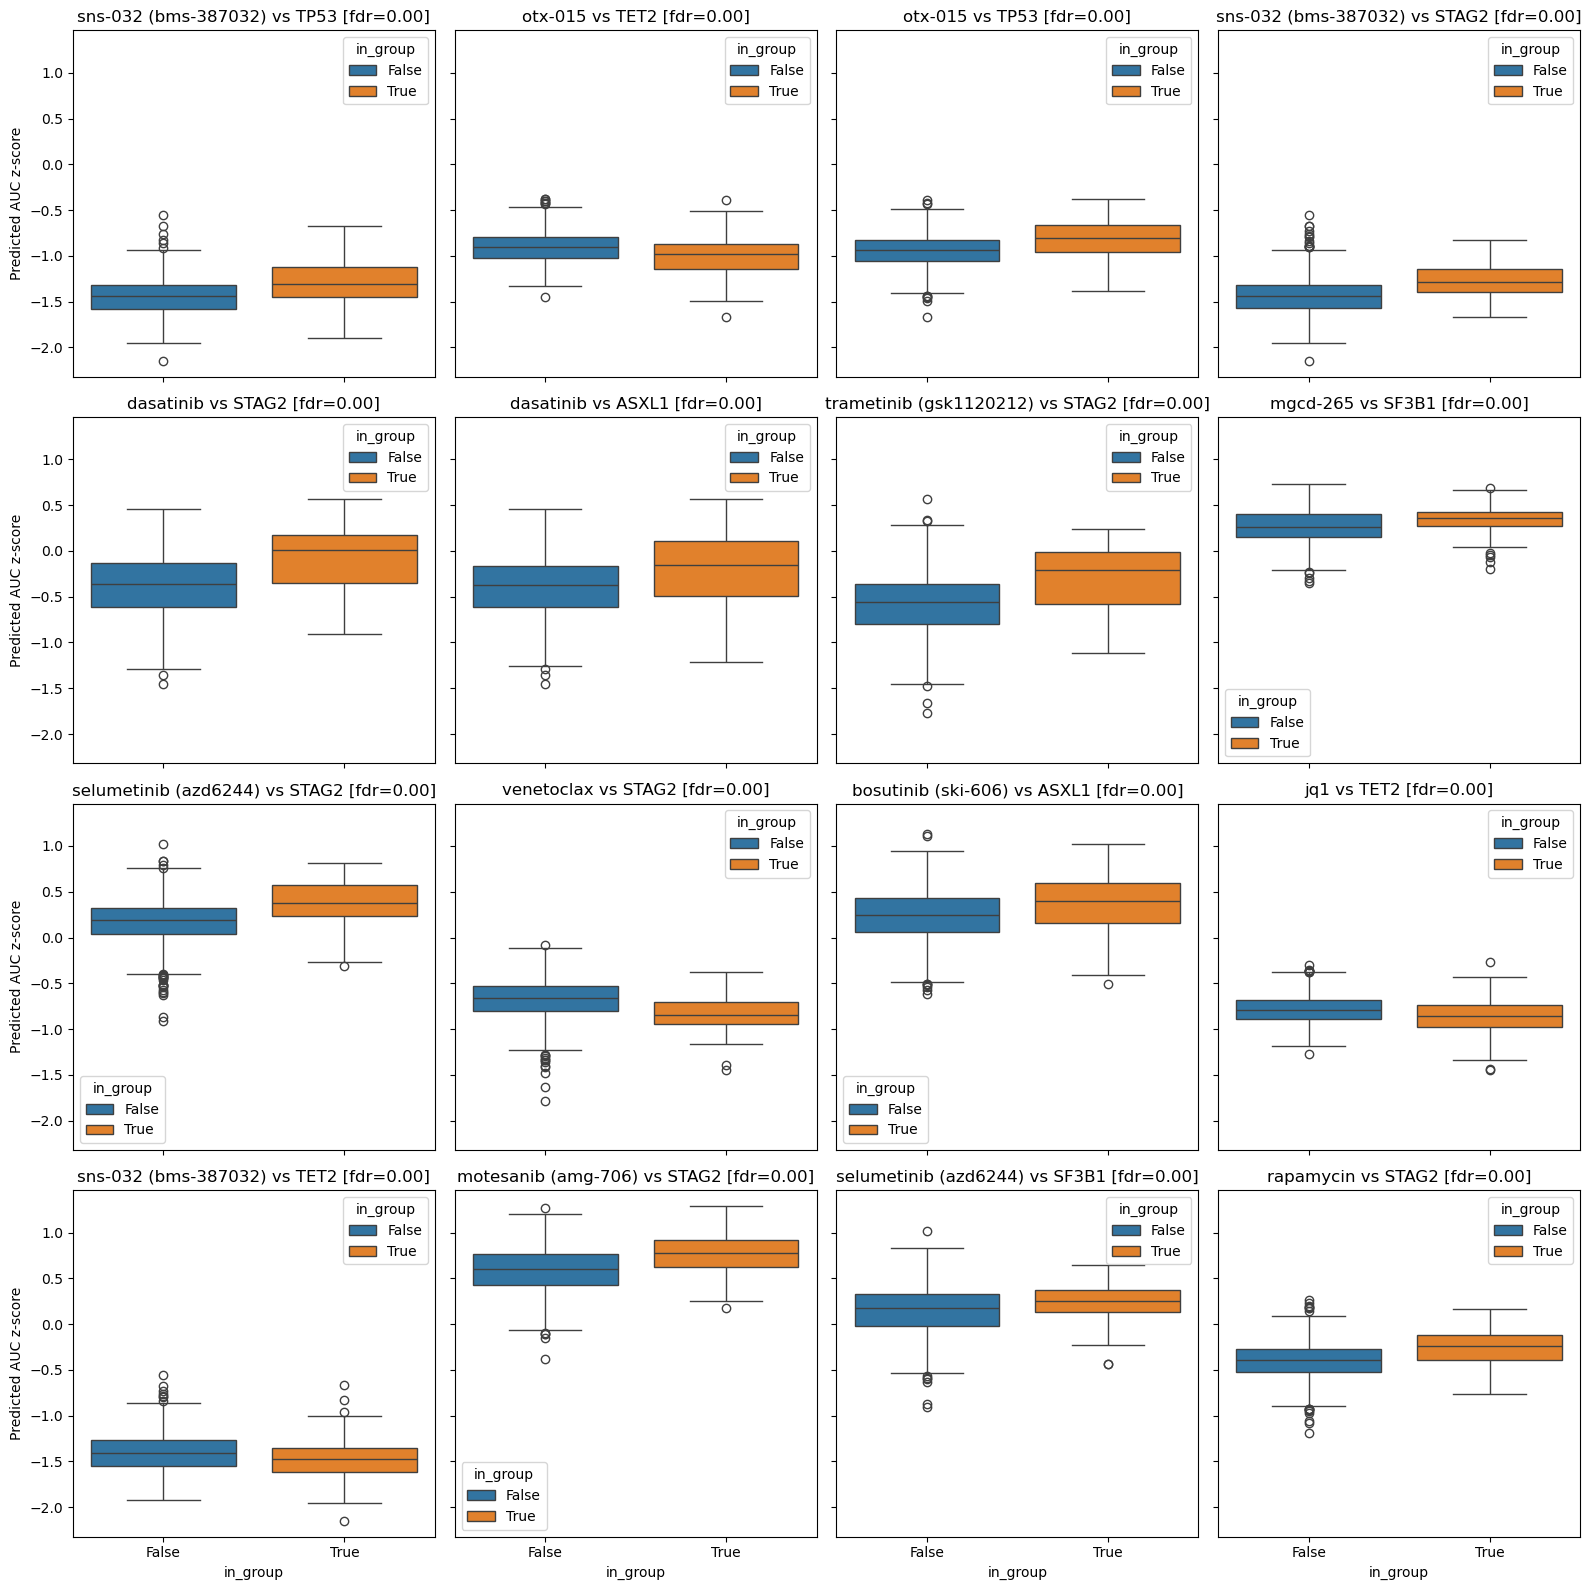

In [74]:
fig, axes = plt.subplots(4,4, figsize=(16, 16), sharey=True, sharex=True)

for i, row in res.sort_values('fdr', ascending=True).head(16).reset_index(drop=True).iterrows(): 

    mut_group = row.mut_subgroup
    subgroup_ids = mds_muts[lambda x: x[mut_group] == 'POSITIVE']['MLL ID'].unique().tolist()
    tmp = mds_preds[lambda x: (x.inhibitor_1 == row.drug1) & (x.inhibitor_2.isna())].assign(in_group = lambda x: x.id.isin(subgroup_ids))

    axes.flat[i].set_title(f'{row.drug1} vs {mut_group} [fdr={row.fdr:.2f}]')
    sbn.boxplot(data=tmp, x='in_group', y='yhat', hue='in_group', ax=axes.flat[i]) 
    axes.flat[i].set_ylabel('Predicted AUC z-score')

plt.tight_layout()
plt.show() 



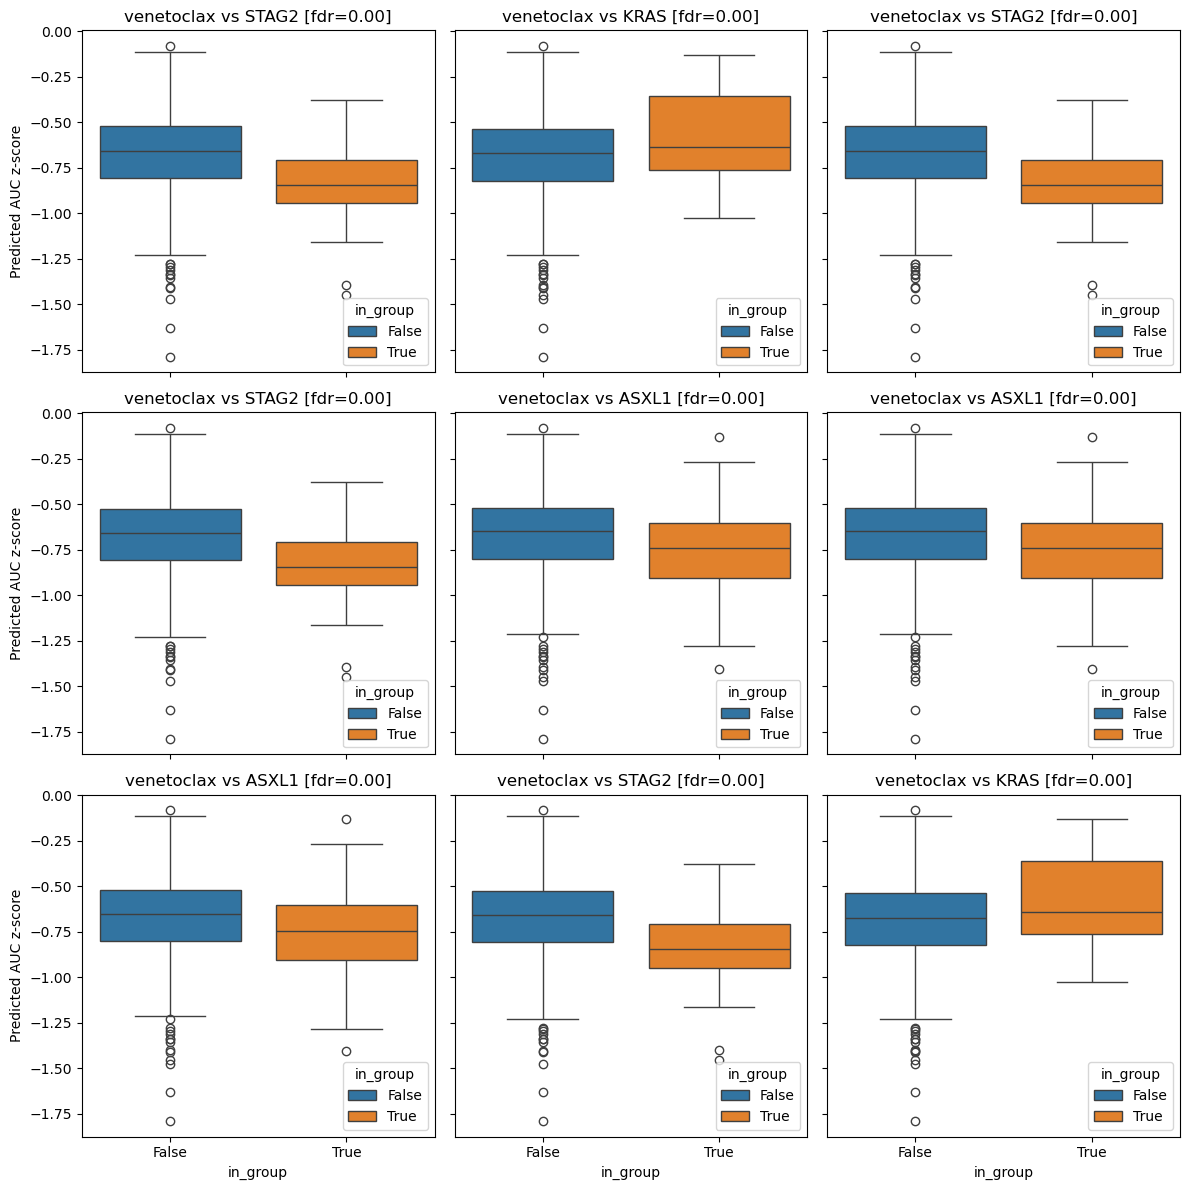

In [ ]:
fig, axes = plt.subplots(3,3, figsize=(12, 12), sharey=True, sharex=True)

for i, row in res_ven.sort_values('fdr', ascending=True).head(9).reset_index(drop=True).iterrows(): 

    mut_group = row.mut_subgroup
    subgroup_ids = mds_muts[lambda x: x[mut_group] == 'POSITIVE']['MLL ID'].unique().tolist()
    tmp = mds_preds[lambda x: (x.inhibitor_1 == 'vene') & (x.inhibitor_2.isna())].assign(in_group = lambda x: x.id.isin(subgroup_ids))

    axes.flat[i].set_title(f'{row.drug1} vs {mut_group} [fdr={row.fdr:.2f}]')
    sbn.boxplot(data=tmp, x='in_group', y='yhat', hue='in_group', ax=axes.flat[i]) 
    axes.flat[i].set_ylabel('Predicted AUC z-score')

plt.tight_layout()
plt.show() 

# Ven. combination Synergy (within subgroups) 

In [96]:
res_all = pd.concat([res, res_ven])

def get_synergy(drug1, drug2, mut): 

    tmp1 = res_all[lambda x: (x.drug1 == drug1) & (x.drug2.isna()) & (x.mut_subgroup == mut)]
    tmp2 = res_all[lambda x: (x.drug1 == drug2) & (x.drug2.isna()) & (x.mut_subgroup == mut)]
    tmp12 = res_all[lambda x: (x.drug1 == drug1) & (x.drug2 == drug2) & (x.mut_subgroup == mut)]

    delta_improvement_synergy = tmp12.mean_diff.mean() - min(tmp1.mean_diff.mean(), tmp2.mean_diff.mean())
    
    syn_dict = {'synergy':delta_improvement_synergy, 'drug1_mean_diff':tmp1.mean_diff.mean(), 'drug2_mean_diff':tmp2.mean_diff.mean(), 'drug12_mean_diff':tmp12.mean_diff.mean()}
    return syn_dict 


drug1 = 'venetoclax'  

syn_res = {'drug1':[], 'drug2':[], 'mut':[], 'synergy':[], 'drug1_mean_diff':[], 'drug2_mean_diff':[], 'drug12_mean_diff':[]}
for drug2 in res_all.drug2.unique().tolist(): 
    for mut in res_all.mut_subgroup.unique().tolist(): 
        if drug2 == None: continue  
        syn_res['drug1'].append(drug1)
        syn_res['drug2'].append(drug2)
        syn_res['mut'].append(mut)
        syn_dict = get_synergy(drug1, drug2, mut)
        syn_res['synergy'].append(syn_dict['synergy'])
        syn_res['drug1_mean_diff'].append(syn_dict['drug1_mean_diff'])
        syn_res['drug2_mean_diff'].append(syn_dict['drug2_mean_diff'])
        syn_res['drug12_mean_diff'].append(syn_dict['drug12_mean_diff'])

syn_res = pd.DataFrame(syn_res)
syn_res.sort_values('synergy', ascending=True).head(20)



,drug1,drug2,mut,synergy,drug1_mean_diff,drug2_mean_diff,drug12_mean_diff
387,venetoclax,nvp-tae684,CEBPA,-0.065883,-0.177188,-0.152606,-0.243071
393,venetoclax,nvp-tae684,BCOR,-0.046200,-0.084954,-0.172435,-0.218635
389,venetoclax,nvp-tae684,STAG2,-0.046139,-0.158139,-0.129547,-0.204278
681,venetoclax,sunitinib,BCOR,-0.046114,-0.084954,-0.135275,-0.181389
675,venetoclax,sunitinib,CEBPA,-0.041285,-0.177188,-0.078968,-0.218473
905,venetoclax,gilteritinib,BCOR,-0.039111,-0.084954,-0.041173,-0.124064
682,venetoclax,sunitinib,SF3B1,-0.036016,0.029857,0.007443,-0.028573
906,venetoclax,gilteritinib,SF3B1,-0.034199,0.029857,0.023961,-0.010238
394,venetoclax,nvp-tae684,SF3B1,-0.029156,0.029857,0.013955,-0.015201
320,venetoclax,mgcd-265,TP53,-0.026226,-0.087004,-0.051563,-0.113229


In [99]:
syn_res.sort_values('synergy', ascending=True).head(20)[lambda x: x.mut == 'KRAS']


,drug1,drug2,mut,synergy,drug1_mean_diff,drug2_mean_diff,drug12_mean_diff


In [ ]:
# power calculation 
# use 